<a href="https://colab.research.google.com/github/cashby-890/ST-554-HW5/blob/main/ST554_Homework_Five_Cody_Ashby.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ST 554 Spring 2026 Homework Five by Cody Ashby**

## ***Part I: Concepts of Big Data***

1. A topic where the "Five V's of Big Data" could come into play that's of particular interest to me is multivariate and longitudinal statistics. Procedures like cluster analysis and techniques derived from multivariate regression (e.g. principal components analysis and factor analysis) can be used to simplify the *volume*, *value*, and *veracity* aspects by simultaneously studying relationships between multiple variables. Also, linear mixed models and growth curves can be used to accurately make predictions based on incoming data, which covers the *velocity* of big data. The flexibility of these techniques and more can assist in navigating the *variety* of data types and sources we may be interested in analyzing.

2. As a refresher, and to remind myself as well, a `CRUD` process in Structured Query Language (i.e. SQL) allows us to **create**, **read**, **update**, and **delete** data.

* **CREATE**: In the `Lahman.db` database, every SQL statement begins with the `CREATE TABLE` command. If necessary, we can also add more rows using the `INSERT INTO` command and applying it to a particular table in that database.
* **READ**: If we want to retrieve certain info from this database, we can use `SELECT` and other commands like `FROM` and `WHERE` to place certain conditions on what exactly we're looking for.
* **UPDATE**: If we wanted to include statistice from more recently played MLB games, this is where `UPDATE` will come in.
* **DELETE**: If something was typed in erroneously, we can use `DELETE FROM` or even `DROP TABLE` if we find that keeping records of such data is no longer relevant.

3. In SQL, the `HAVING` clause in the `SELECT` statement allows us to apply a specific criteria after filtering by group. However, this can only be used after the `GROUP BY` command. Using `HAVING` by itself will give you an error.



## ***Part II: Simulation of Sampling Distribution***

4. Note: this is my first time simulating a sampling distribution here in Python. Let's see what happens!

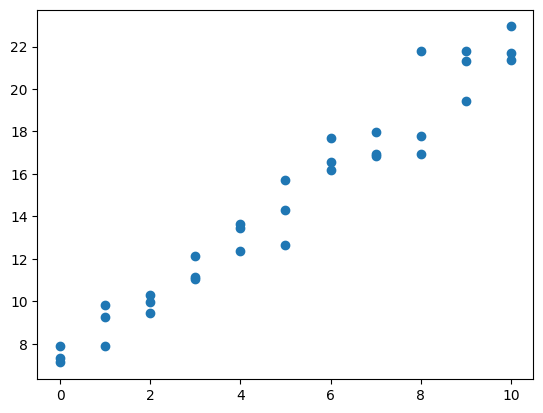

In [ ]:
#Import appropriate modules
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
rng=default_rng(32)
beta_0=7
beta_1=1.5
#Gets three values of x at each integer from 0 to 10
x=np.array(list(np.linspace(0,10,11))*3)
n=33
#Simple Linear Regression Model with Normally-Distributed Standard Error
y=beta_0+beta_1*x+rng.standard_normal(n)
#Produces a scatterplot for the data
plt.scatter(x,y)
plt.show()

Next, we'll use `LinearRegression` from the `sklearn` module to fit a regression line for this data. We're only interested in an estimate for the slope

In [ ]:
from sklearn.linear_model import LinearRegression
reg=LinearRegression()
model=reg.fit(x.reshape(-1,1),y)
model.coef_[0]

np.float64(1.4745056382493755)

Okay, that was just one sample slope. We'll need to do 5000 of these. Here's where a `for` loop comes in.

Text(0.5, 1.0, 'Histogram of Sample Slopes for SLR Simulation')

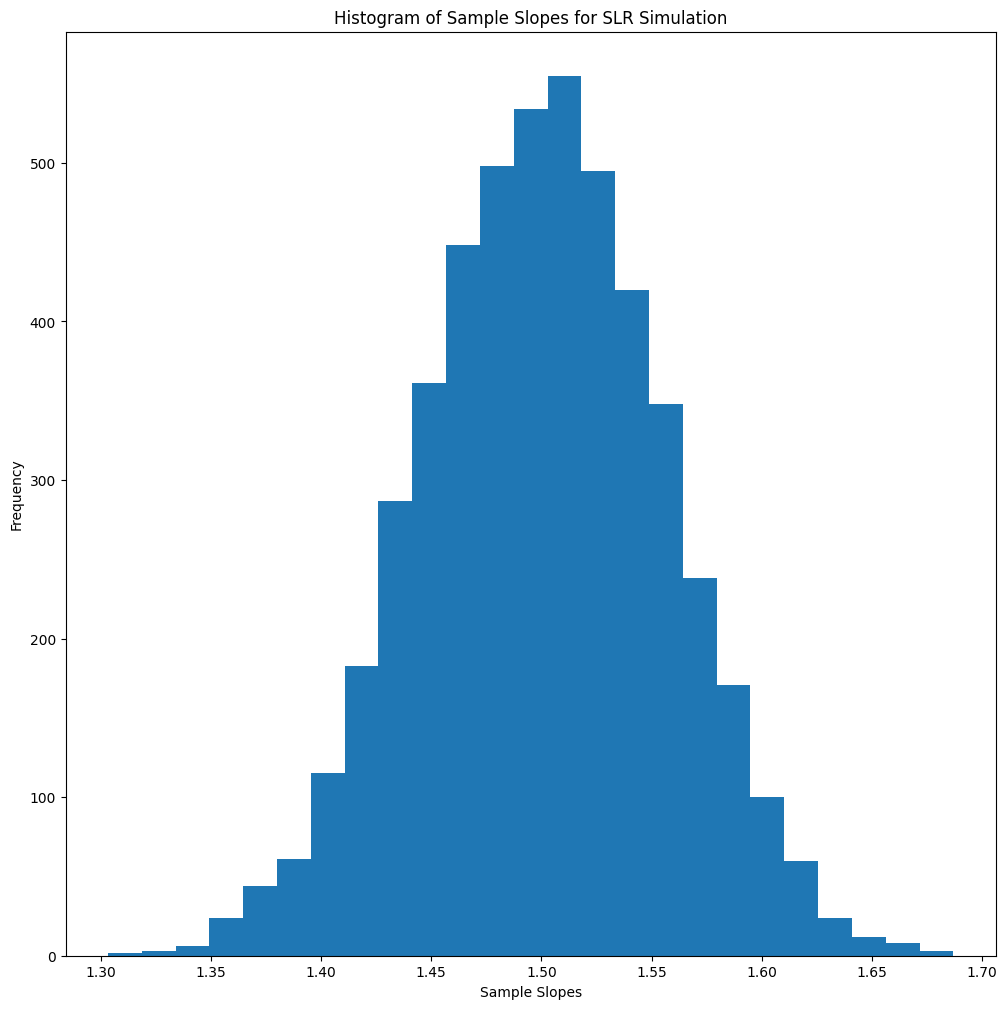

In [ ]:
#Initialize a 1D numpy array to store the sample slopes.
sample_slopes=np.zeros(shape=(5000,1))
#The for loop to generate these sample slopes.
for i in range(5000):
    y=beta_0+beta_1*x+rng.standard_normal(n)
    model=reg.fit(x.reshape(-1,1),y)
    sample_slopes[i]=model.coef_[0]

#Below is the histogram that illustrates the sampling distribution of the sample slopes generated from the for loop above.
plt.subplots(figsize=(12,12))
plt.hist(sample_slopes,bins=25)
plt.xlabel('Sample Slopes')
plt.ylabel('Frequency')
plt.title('Histogram of Sample Slopes for SLR Simulation')

Now, we can use this sampling distribution to find the probability of observing a sample slope that's larger than 1.65.

In [ ]:
sample_slope_probability=sum(sample_slopes>1.65)/len(sample_slopes)
print(sample_slope_probability[0])

0.0038


What this means is that there's a 0.38% chance of observing a sample slope larger than 1.65, which is pretty small. In the context of a hypothesis test, this would translate to a p-value of 0.0038, which  would lead us to rejecting the claim of having a sample slope larger than 1.65.

## ***Part III: Examples of Big Data and Rare Events***

5. In the Milaninia article, one example that involves reporting bias
pertains to distinguishing between social media producers and consumers. That is, although "22% of the US population" has a Twitter account, only 10% of those produce 80% of all tweets. One could mistakenly infer that 22% of the US population actually uses Twitter and perhaps go even further by suggesting that 80% of all tweets come from those same people.

    *   One way to remedy this would be to

6.

7.

## ***Part IV: Querying a Database***

8. First, we'll need to import the `sqlite3` module in order to make any connections.

In [ ]:
import sqlite3
con = sqlite3.connect("lahman_1871-2022.sqlite")

Next, we'll set up the schema to retrieve all the tables...

In [ ]:
cursor = con.cursor()
get_schema='''
        select *
        from sqlite_schema
        where type="table";
        '''
cursor.execute(get_schema)
result=cursor.fetchall()
cursor.close()

Finally, we'll return this as a dataframe so we can see all the tables.

In [ ]:
import pandas as pd
lahman_df=pd.read_sql(get_schema,con)
lahman_df

,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


9. Here are the teams that played in 2015 using an SQL query to retrieve information from the `Teams` table.

In [ ]:
pd.read_sql("select * from Teams where yearID=2015;",con)

,yearID,lgID,teamID,franchID,divID,Rank,G,Ghome,W,L,...,DP,FP,name,park,attendance,BPF,PPF,teamIDBR,teamIDlahman45,teamIDretro
0,2015,AL,BAL,BAL,E,3,162,78,81,81,...,134,0.987,Baltimore Orioles,Oriole Park at Camden Yards,2281202,103,104,BAL,BAL,BAL
1,2015,AL,BOS,BOS,E,5,162,81,78,84,...,148,0.984,Boston Red Sox,Fenway Park II,2880694,104,107,BOS,BOS,BOS
2,2015,AL,CHA,CHW,C,4,162,81,76,86,...,159,0.983,Chicago White Sox,U.S. Cellular Field,1755810,92,93,CHW,CHA,CHA
3,2015,AL,CLE,CLE,C,3,161,80,81,80,...,136,0.987,Cleveland Indians,Progressive Field,1388905,106,106,CLE,CLE,CLE
4,2015,AL,DET,DET,C,5,161,81,74,87,...,165,0.986,Detroit Tigers,Comerica Park,2726048,97,98,DET,DET,DET
5,2015,AL,HOU,HOU,W,2,162,81,86,76,...,131,0.986,Houston Astros,Minute Maid Park,2153585,97,99,HOU,HOU,HOU
6,2015,AL,KCA,KCR,C,1,162,81,95,67,...,138,0.985,Kansas City Royals,Kauffman Stadium,2708549,104,103,KCR,KCA,KCA
7,2015,AL,LAA,ANA,W,3,162,81,85,77,...,108,0.984,Los Angeles Angels of Anaheim,Angel Stadium of Anaheim,3012765,94,95,LAA,ANA,ANA
8,2015,AL,MIN,MIN,C,2,162,81,83,79,...,150,0.986,Minnesota Twins,Target Field,2220054,103,104,MIN,MIN,MIN
9,2015,AL,NYA,NYY,E,2,162,81,87,75,...,135,0.985,New York Yankees,Yankee Stadium III,3193795,99,101,NYY,NYA,NYA


10. Here is another SQL query that returns all of the players that were inducted into the Hall of Fame, alone with their respective years.

In [ ]:
pd.read_sql("select playerID,yearid,inducted,category from HallOfFame where inducted='Y';",con)

,playerID,yearid,inducted,category
0,aaronha01,1982,Y,Player
1,alexape01,1938,Y,Player
2,alomaro01,2011,Y,Player
3,alstowa01,1983,Y,Manager
4,andersp01,2000,Y,Manager
...,...,...,...,...
335,yastrca01,1989,Y,Player
336,yawketo99,1980,Y,Pioneer/Executive
337,youngcy01,1937,Y,Player
338,youngro01,1972,Y,Player


11. Here are all of the managers of the Pittsburgh Pirates from the `Managers` table.

In [ ]:
pd.read_sql("select distinct * from Managers where teamID='PIT' and plyrMgr='Y'",con)

,playerID,yearID,teamID,lgID,inseason,G,W,L,rank,plyrMgr
0,dunlafr01,1889,PIT,NL,2,17,7,10,5,Y
1,hanlone01,1889,PIT,NL,3,46,26,18,5,Y
2,heckegu01,1890,PIT,NL,1,138,23,113,8,Y
3,hanlone01,1891,PIT,NL,1,78,31,47,8,Y
4,burnsto01,1892,PIT,NL,2,60,27,32,4,Y
5,mackco01,1894,PIT,NL,2,23,12,10,7,Y
6,mackco01,1895,PIT,NL,1,135,71,61,7,Y
7,mackco01,1896,PIT,NL,1,131,66,63,6,Y
8,donovpa01,1897,PIT,NL,1,135,60,71,8,Y
9,donovpa01,1899,PIT,NL,2,131,69,58,7,Y


12. Next up are the people that managed for a team that were inducted into the Hall of Fame.

In [ ]:
left="""
    select distinct M.playerID from Managers as M
    left join HallofFame as H on H.playerID=M.playerID
    where H.inducted='Y' and M.plyrMgr='Y'
    """
inducted_managers=pd.read_sql(left,con)
inducted_managers

,playerID
0,ansonca01
1,bancrda01
2,bottoji01
3,boudrlo01
4,bresnro01
...,...
58,wardjo01
59,whitede01
60,wrighge01
61,wrighha01


Let's use a simple command to find how many of these managers there are.

In [ ]:
len(inducted_managers)

63

13. Lastly, we'll use the `HallOfFame` and `Managers` tables to find every season managed by each manager that made it into the Hall of Fame, using only a handful of coumns from the latter table.

In [ ]:
outer="""
  select distinct M.playerID, M.G, M.W, M.L from Managers as M
  inner join HallOfFame as H on H.playerID=M.playerID
  where H.inducted='Y' and M.plyrMgr='Y'
  """
inducted_manager_scoring_stats=pd.read_sql(outer,con)
inducted_manager_scoring_stats


,playerID,G,W,L
0,ansonca01,8,4,2
1,ansonca01,64,41,21
2,ansonca01,86,67,17
3,ansonca01,84,56,28
4,ansonca01,84,55,29
...,...,...,...,...
279,wrighha01,71,52,18
280,wrighha01,82,71,8
281,wrighha01,70,39,31
282,wrighha01,61,42,18


In [ ]:
inducted_manager_WinLoss=inducted_manager_scoring_stats.groupby('playerID')[['W','L']].sum()
inducted_manager_WinLoss

,W,L
playerID,,
ansonca01,1287,934
bancrda01,249,363
bottoji01,21,56
boudrlo01,804,727
bresnro01,265,342
...,...,...
wardjo01,412,320
whitede01,9,11
wrighge01,59,25


In [ ]:
inducted_manager_WinLoss['Percentage']=inducted_manager_WinLoss['W']/(inducted_manager_WinLoss['W']+inducted_manager_WinLoss['L'])
inducted_manager_WinLoss['Percentage']

,Percentage
playerID,
ansonca01,0.579469
bancrda01,0.406863
bottoji01,0.272727
boudrlo01,0.525147
bresnro01,0.436573
...,...
wardjo01,0.562842
whitede01,0.450000
wrighge01,0.702381


In [ ]:
inducted_manager_WinLoss.Percentage.sort_values(ascending=False)

,Percentage
playerID,
wrighha01,0.737349
wrighge01,0.702381
spaldal01,0.624000
chancfr01,0.613731
comisch01,0.608255
...,...
robinwi01,0.296296
galvipu01,0.291667
bottoji01,0.272727
